# Assignment 4: AI-Assisted Python Statistics Walkthrough

This notebook uses an AI-generated workflow to analyze the same datasets used in the manual walkthrough. The analysis includes data inspection, descriptive statistics, hypothesis testing, regression, visualization, and interaction analysis.

The code in this notebook was independently organized and generated with AI rather than copied directly from the original tutorial.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1. Brain-Size Dataset

This section loads the brain-size dataset and checks its structure, missing values, and basic summary statistics before performing the analysis.

In [2]:
# Load the brain-size dataset.

brain = pd.read_csv(
    "../examples/brain_size.csv",
    sep=";",
    na_values=".",
    index_col=0
)

print("Dataset shape:", brain.shape)

brain.head()

Dataset shape: (40, 7)


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545


### Initial Data Inspection

The dataset is checked for data types, missing values, and basic descriptive statistics.

In [3]:
# Display information about the columns and data types.

brain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 1 to 40
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gender     40 non-null     object 
 1   FSIQ       40 non-null     int64  
 2   VIQ        40 non-null     int64  
 3   PIQ        40 non-null     int64  
 4   Weight     38 non-null     float64
 5   Height     39 non-null     float64
 6   MRI_Count  40 non-null     int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 2.5+ KB


In [4]:
# Count missing values in each column.

brain.isna().sum()

Gender       0
FSIQ         0
VIQ          0
PIQ          0
Weight       2
Height       1
MRI_Count    0
dtype: int64

In [5]:
# Display descriptive statistics for the numerical variables.

brain.describe()

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.00000,38.000000,39.000000,4.000000e+01
mean,113.450000,112.350000,111.02500,151.052632,68.525641,9.087550e+05
std,24.082071,23.616107,22.47105,23.478509,3.994649,7.228205e+04
min,77.000000,71.000000,72.00000,106.000000,62.000000,7.906190e+05
25%,89.750000,90.000000,88.25000,135.250000,66.000000,8.559185e+05
50%,116.500000,113.000000,115.00000,146.500000,68.000000,9.053990e+05
75%,135.500000,129.750000,128.00000,172.000000,70.500000,9.500780e+05
max,144.000000,150.000000,150.00000,192.000000,77.000000,1.079549e+06


The dataset contains 40 participants and seven variables. The IQ measurements, MRI count, and gender are complete, while weight and height contain some missing values. Missing observations will be removed only when those variables are used in a specific analysis.

### Summary Statistics by Gender

The following table compares sample size and average measurements between female and male participants.

In [6]:
# Calculate summary statistics for each gender group.

gender_summary = brain.groupby("Gender").agg(
    sample_size=("VIQ", "size"),
    mean_FSIQ=("FSIQ", "mean"),
    mean_VIQ=("VIQ", "mean"),
    mean_PIQ=("PIQ", "mean"),
    mean_weight=("Weight", "mean"),
    mean_height=("Height", "mean"),
    mean_MRI_Count=("MRI_Count", "mean")
)

gender_summary

,sample_size,mean_FSIQ,mean_VIQ,mean_PIQ,mean_weight,mean_height,mean_MRI_Count
Gender,,,,,,,
Female,20,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,20,115.0,115.25,111.60,166.444444,71.431579,954855.4


The sample means show some differences between female and male participants. However, statistical tests are needed to determine whether these observed differences are statistically significant.

### Visual Exploration

Scatter matrices are used to examine the distributions and relationships among the physical measurements and IQ scores.

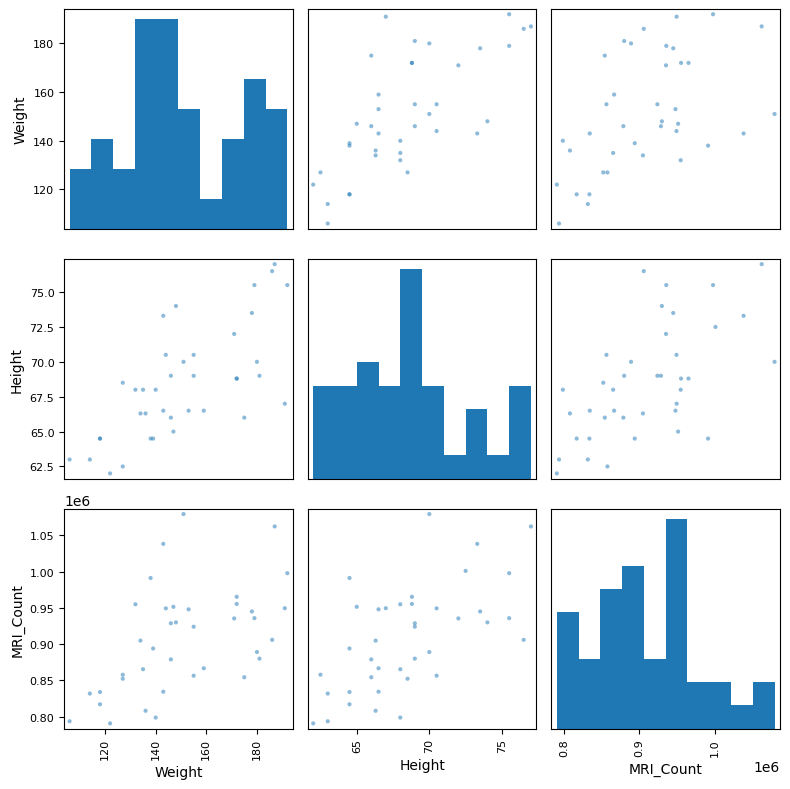

In [7]:
# Examine relationships among weight, height, and MRI count.

pd.plotting.scatter_matrix(
    brain[["Weight", "Height", "MRI_Count"]],
    figsize=(8, 8)
)

plt.tight_layout()
plt.show()

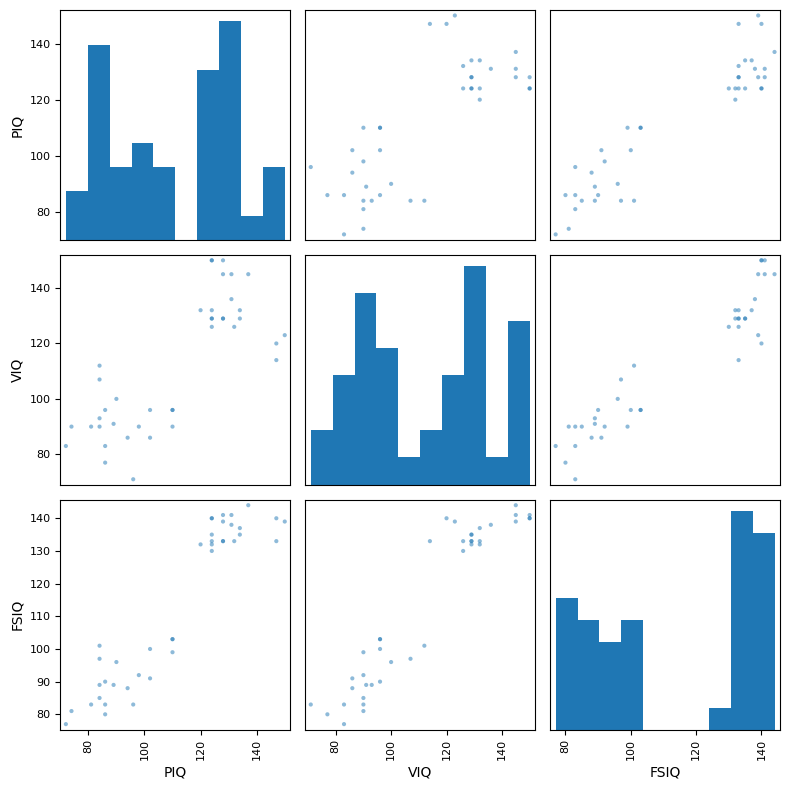

In [8]:
# Examine relationships among the three IQ measurements.

pd.plotting.scatter_matrix(
    brain[["PIQ", "VIQ", "FSIQ"]],
    figsize=(8, 8)
)

plt.tight_layout()
plt.show()

The three IQ measurements show strong positive relationships. Participants with higher scores on one IQ measurement generally also have higher scores on the other measurements. The plots also help identify possible clusters and unusual observations before formal testing.

## 2. Hypothesis Testing

### Comparison of Female and Male VIQ Scores

The first analysis compares the VIQ scores of female and male participants using both a parametric and a nonparametric test.

In [9]:
# Separate VIQ scores by gender and remove any missing values.

female_viq = brain.loc[
    brain["Gender"] == "Female",
    "VIQ"
].dropna()

male_viq = brain.loc[
    brain["Gender"] == "Male",
    "VIQ"
].dropna()

viq_summary = pd.DataFrame({
    "Group": ["Female", "Male"],
    "Sample Size": [len(female_viq), len(male_viq)],
    "Mean VIQ": [female_viq.mean(), male_viq.mean()],
    "Standard Deviation": [
        female_viq.std(ddof=1),
        male_viq.std(ddof=1)
    ]
})

viq_summary

,Group,Sample Size,Mean VIQ,Standard Deviation
0,Female,20,109.45,21.670924
1,Male,20,115.25,25.640993


In [10]:
# Perform an independent two-sample t-test.

viq_ttest = sp.stats.ttest_ind(
    female_viq,
    male_viq
)

print("Independent two-sample t-test")
print("Test statistic:", viq_ttest.statistic)
print("P-value:", viq_ttest.pvalue)

Independent two-sample t-test
Test statistic: -0.7726161723275012
P-value: 0.44452876778583217


In [11]:
# Perform a Mann-Whitney U test as a nonparametric comparison.

viq_mannwhitney = sp.stats.mannwhitneyu(
    female_viq,
    male_viq,
    alternative="two-sided"
)

print("Mann-Whitney U test")
print("Test statistic:", viq_mannwhitney.statistic)
print("P-value:", viq_mannwhitney.pvalue)

Mann-Whitney U test
Test statistic: 164.5
P-value: 0.3422886868727315


Both tests produce p-values greater than 0.05. Therefore, the analysis does not provide enough evidence to conclude that female and male participants have significantly different VIQ scores. Although the sample means are not identical, the observed difference could reasonably be caused by sampling variation.

### One-Sample Tests for VIQ

The following tests compare the VIQ scores with a reference value of zero. This is mainly used to demonstrate one-sample statistical testing because zero is not a realistic average IQ value.

In [12]:
# Perform a one-sample t-test comparing mean VIQ with zero.

viq_one_sample_t = sp.stats.ttest_1samp(
    brain["VIQ"],
    popmean=0
)

print("One-sample t-test")
print("Test statistic:", viq_one_sample_t.statistic)
print("P-value:", viq_one_sample_t.pvalue)

One-sample t-test
Test statistic: 30.08809997084933
P-value: 1.3289196468727879e-28


In [13]:
# Perform a one-sample Wilcoxon signed-rank test.

viq_one_sample_wilcoxon = sp.stats.wilcoxon(
    brain["VIQ"]
)

print("One-sample Wilcoxon test")
print("Test statistic:", viq_one_sample_wilcoxon.statistic)
print("P-value:", viq_one_sample_wilcoxon.pvalue)

One-sample Wilcoxon test
Test statistic: 0.0
P-value: 3.488172636231201e-08


Both one-sample tests produce very small p-values. Therefore, the VIQ values are significantly different from zero. However, this result is mainly useful as a demonstration of the statistical methods because zero is not a meaningful expected VIQ score.

### Paired Comparison of FSIQ and PIQ

FSIQ and PIQ were measured on the same participants. Because the measurements are paired, tests that preserve the connection between each participant's two scores are appropriate.

In [14]:
# Keep participants who have both FSIQ and PIQ values.

paired_iq = brain[["FSIQ", "PIQ"]].dropna()

paired_summary = pd.DataFrame({
    "Measurement": ["FSIQ", "PIQ"],
    "Mean": [
        paired_iq["FSIQ"].mean(),
        paired_iq["PIQ"].mean()
    ],
    "Standard Deviation": [
        paired_iq["FSIQ"].std(ddof=1),
        paired_iq["PIQ"].std(ddof=1)
    ]
})

paired_summary

,Measurement,Mean,Standard Deviation
0,FSIQ,113.450,24.082071
1,PIQ,111.025,22.471050


In [15]:
# Perform a paired t-test.

paired_ttest = sp.stats.ttest_rel(
    paired_iq["FSIQ"],
    paired_iq["PIQ"]
)

print("Paired t-test")
print("Test statistic:", paired_ttest.statistic)
print("P-value:", paired_ttest.pvalue)

Paired t-test
Test statistic: 1.7842019405859857
P-value: 0.08217263818364236


In [16]:
# Perform a paired Wilcoxon signed-rank test.

paired_wilcoxon = sp.stats.wilcoxon(
    paired_iq["FSIQ"],
    paired_iq["PIQ"],
    method="approx"
)

print("Paired Wilcoxon test")
print("Test statistic:", paired_wilcoxon.statistic)
print("P-value:", paired_wilcoxon.pvalue)

Paired Wilcoxon test
Test statistic: 274.5
P-value: 0.10659492713506856


In [17]:
# Calculate the difference between the paired measurements.

paired_iq = paired_iq.assign(
    Difference=paired_iq["FSIQ"] - paired_iq["PIQ"]
)

paired_iq["Difference"].describe()

count    40.000000
mean      2.425000
std       8.596026
min     -14.000000
25%      -6.000000
50%       4.500000
75%       8.250000
max      17.000000
Name: Difference, dtype: float64

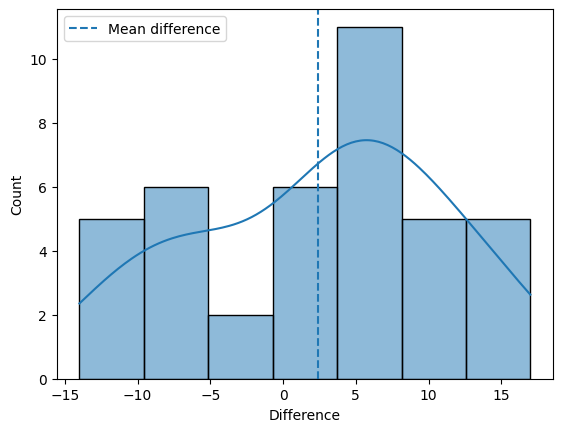

In [18]:
# Visualize the paired differences.

sns.histplot(
    data=paired_iq,
    x="Difference",
    kde=True
)

plt.axvline(
    paired_iq["Difference"].mean(),
    linestyle="--",
    label="Mean difference"
)

plt.legend()
plt.show()

The paired t-test and paired Wilcoxon test both produce p-values greater than 0.05. Therefore, the data do not provide enough evidence that FSIQ and PIQ are significantly different. The positive mean difference shows that FSIQ was slightly higher on average, but the difference was not statistically significant.

### Comparison of Female and Male Weight

Weight contains missing values, so incomplete observations are removed before the two groups are compared.

In [19]:
# Separate weight values by gender and remove missing observations.

female_weight = brain.loc[
    brain["Gender"] == "Female",
    "Weight"
].dropna()

male_weight = brain.loc[
    brain["Gender"] == "Male",
    "Weight"
].dropna()

weight_summary = pd.DataFrame({
    "Group": ["Female", "Male"],
    "Sample Size": [
        len(female_weight),
        len(male_weight)
    ],
    "Mean Weight": [
        female_weight.mean(),
        male_weight.mean()
    ],
    "Standard Deviation": [
        female_weight.std(ddof=1),
        male_weight.std(ddof=1)
    ]
})

weight_summary

,Group,Sample Size,Mean Weight,Standard Deviation
0,Female,20,137.200000,16.953807
1,Male,18,166.444444,20.047656


In [20]:
# Perform an independent two-sample t-test.

weight_ttest = sp.stats.ttest_ind(
    female_weight,
    male_weight,
    equal_var=True
)

print("Independent two-sample t-test for weight")
print("Test statistic:", weight_ttest.statistic)
print("P-value:", weight_ttest.pvalue)

Independent two-sample t-test for weight
Test statistic: -4.870950921940696
P-value: 2.227293018362118e-05


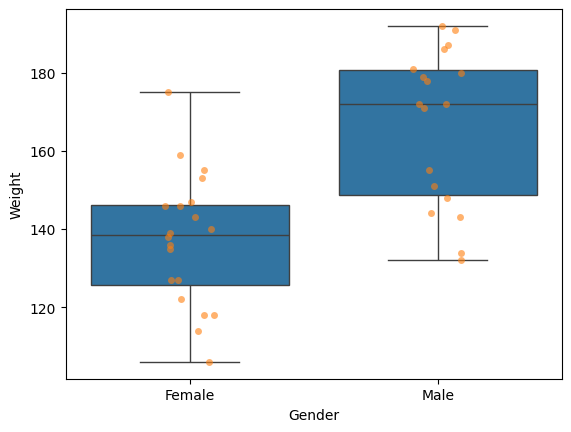

In [21]:
# Visualize the weight distributions by gender.

weight_plot_data = brain[
    ["Gender", "Weight"]
].dropna()

sns.boxplot(
    data=weight_plot_data,
    x="Gender",
    y="Weight"
)

sns.stripplot(
    data=weight_plot_data,
    x="Gender",
    y="Weight",
    alpha=0.6
)

plt.show()

The p-value is much smaller than 0.05, so the null hypothesis is rejected. Female and male participants had significantly different mean weights in this sample. The negative test statistic shows that the female group had a lower mean weight than the male group.

## 3. Regression Analysis

### Simple Linear Regression

A simulated dataset is used to demonstrate how linear regression estimates the relationship between an independent variable and a dependent variable.

In [22]:
# Generate reproducible simulated data.

x = np.linspace(-5, 5, 20)

rng = np.random.default_rng(27446968)

y = -5 + 3 * x + 4 * rng.normal(
    size=x.shape
)

simulated_data = pd.DataFrame({
    "x": x,
    "y": y
})

simulated_data.head()

,x,y
0,-5.000000,-21.480061
1,-4.473684,-22.225010
2,-3.947368,-16.407128
3,-3.421053,-7.777809
4,-2.894737,-15.214241


In [23]:
# Fit an ordinary least squares regression model.

simple_model = smf.ols(
    formula="y ~ x",
    data=simulated_data
).fit()

simple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     164.5
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.72e-10
Time:                        01:43:02   Log-Likelihood:                -51.758
No. Observations:                  20   AIC:                             107.5
Df Residuals:                      18   BIC:                             109.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.2948      0.759     -5.661      0.000      -5.889      -2.701
x              3.2060      0.250     12.825      0.000       2.681       3.731
==============================================================================
Omnibus:                        1.218   Durbin-Watson:                   1.796
Prob(Omnibus):                  0.544   Jarque-Bera (JB):                0.999
Skew:                           0.503   Prob(JB):                        0.607
Kurtosis:                       2.568   Cond. No.                         3.03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
# Display the estimated model coefficients.

simple_model.params

Intercept   -4.294824
x            3.205979
dtype: float64

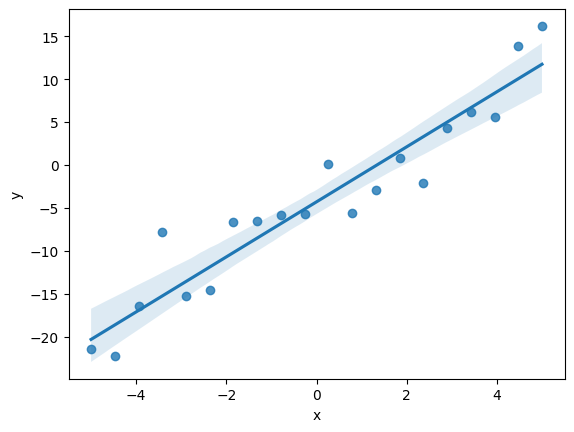

In [25]:
# Plot the observations and fitted regression line.

sns.regplot(
    data=simulated_data,
    x="x",
    y="y",
    ci=95
)

plt.show()

The estimated slope is approximately 3.21, meaning that y increases by about 3.21 units for every one-unit increase in x. The p-value for x is below 0.05, so the linear relationship is statistically significant. The R-squared value shows that the model explains about 90% of the variation in y.

### Gender as a Categorical Predictor of VIQ

This model uses gender as a categorical variable to estimate the difference in mean VIQ between female and male participants.

In [26]:
# Fit a regression model using gender to predict VIQ.

gender_model = smf.ols(
    formula="VIQ ~ Gender",
    data=brain
).fit()

gender_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Tue, 28 Jul 2026   Prob (F-statistic):              0.445
Time:                        01:43:03   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.619      0.000      98.704     120.196
Gender[T.Male]     5.8000      7.507      0.773      0.445      -9.397      20.997
==============================================================================
Omnibus:                       26.188   Durbin-Watson:                   1.709
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                3.703
Skew:                           0.010   Prob(JB):                        0.157
Kurtosis:                       1.510   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
# Display the coefficients and p-values in a smaller table.

gender_results = pd.DataFrame({
    "Coefficient": gender_model.params,
    "P-value": gender_model.pvalues
})

gender_results

,Coefficient,P-value
Intercept,109.45,3.119972e-22
Gender[T.Male],5.80,4.445288e-01


The intercept represents the mean VIQ score for female participants. The coefficient for `Gender[T.Male]` indicates that male participants had an average VIQ score about 5.80 points higher than female participants. However, the p-value is greater than 0.05, so the difference is not statistically significant.

### Multiple Regression for VIQ

This model tests whether gender predicts VIQ after controlling for MRI count, height, and weight.

In [28]:
# Create a complete dataset containing only the variables used in the model.

brain_model_data = brain[
    ["VIQ", "Gender", "MRI_Count", "Height", "Weight"]
].dropna()

print("Original sample size:", len(brain))
print("Complete sample size:", len(brain_model_data))

Original sample size: 40
Complete sample size: 38


In [29]:
# Fit a multiple regression model.

brain_multiple_model = smf.ols(
    formula="VIQ ~ Gender + MRI_Count + Height + Weight",
    data=brain_model_data
).fit()

brain_multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    VIQ   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     2.733
Date:                Tue, 28 Jul 2026   Prob (F-statistic):             0.0455
Time:                        01:43:03   Log-Likelihood:                -167.03
No. Observations:                  38   AIC:                             344.1
Df Residuals:                      33   BIC:                             352.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        169.7719     90.054      1.885      0.068     -13.443     352.987
Gender[T.Male]    10.1579     10.891      0.933      0.358     -12.001      32.317
MRI_Count          0.0002   6.48e-05      2.489      0.018    2.94e-05       0.000
Height            -2.7337      1.410     -1.938      0.061      -5.603       0.136
Weight            -0.1427      0.215     -0.665      0.511      -0.579       0.294
==============================================================================
Omnibus:                        5.002   Durbin-Watson:                   2.272
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                1.892
Skew:                          -0.066   Prob(JB):                        0.388
Kurtosis:                       1.915   Cond. No.                     2.41e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.41e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
# Organize the coefficient estimates and p-values.

brain_multiple_results = pd.DataFrame({
    "Coefficient": brain_multiple_model.params,
    "Standard Error": brain_multiple_model.bse,
    "P-value": brain_multiple_model.pvalues
})

brain_multiple_results

,Coefficient,Standard Error,P-value
Intercept,169.771886,90.053557,0.068229
Gender[T.Male],10.157882,10.891356,0.357772
MRI_Count,0.000161,0.000065,0.018026
Height,-2.733686,1.410294,0.061170
Weight,-0.142724,0.214606,0.510637


After controlling for MRI count, height, and weight, the coefficient for `Gender[T.Male]` is about 10.16. However, its p-value is greater than 0.05, so gender is not a statistically significant predictor of VIQ in this model. MRI count has a p-value below 0.05 and is the only statistically significant predictor included in the model.

### Multiple Regression Diagnostics

Residual plots are used to examine whether the regression model shows major problems with linearity or unequal variation.

In [31]:
# Store fitted values and residuals from the model.

fitted_values = brain_multiple_model.fittedvalues
residuals = brain_multiple_model.resid

diagnostic_data = pd.DataFrame({
    "Fitted Values": fitted_values,
    "Residuals": residuals
})

diagnostic_data.head()

,Fitted Values,Residuals
1,108.278954,23.721046
3,126.513978,-3.513978
4,122.897037,6.102963
5,124.469731,7.530269
6,110.011560,-20.011560


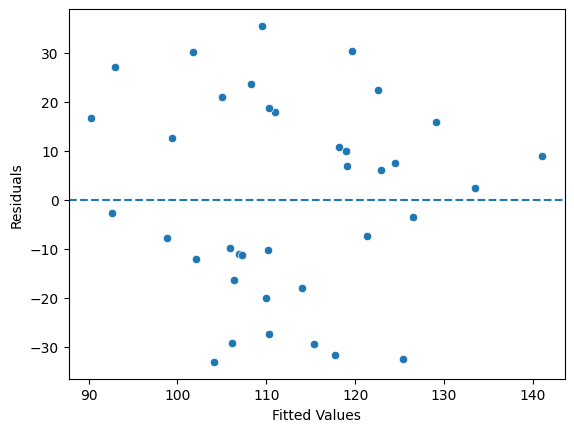

In [32]:
# Plot residuals against fitted values.

sns.scatterplot(
    data=diagnostic_data,
    x="Fitted Values",
    y="Residuals"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.show()

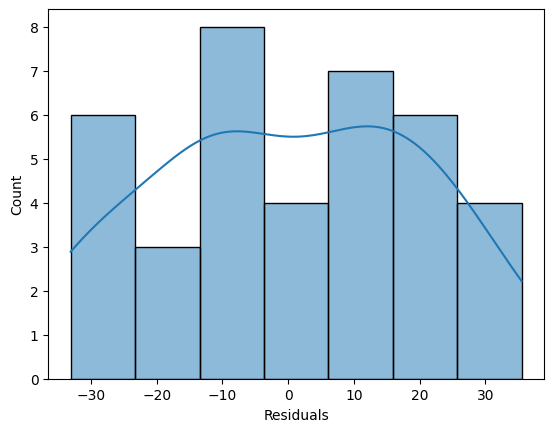

In [33]:
# Display the distribution of the residuals.

sns.histplot(
    data=diagnostic_data,
    x="Residuals",
    kde=True
)

plt.show()

The residual plots help check whether the residuals are centered around zero and whether their spread changes across fitted values. There is no obvious large pattern, although the small sample size makes the diagnostic results less certain.

## 4. Iris Dataset

The iris dataset contains sepal and petal measurements for three iris species. This section uses visualization and multiple regression to examine differences among the species.

In [34]:
# Load the iris dataset.

iris = pd.read_csv(
    "../examples/iris.csv"
)

print("Dataset shape:", iris.shape)

iris.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Iris Data Inspection

In [35]:
# Check the structure and data types.

iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   name          150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [36]:
# Check for missing values.

iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
name            0
dtype: int64

In [37]:
# Calculate mean measurements for each species.

iris_summary = iris.groupby("name").agg(
    sample_size=("sepal_length", "size"),
    mean_sepal_length=("sepal_length", "mean"),
    mean_sepal_width=("sepal_width", "mean"),
    mean_petal_length=("petal_length", "mean"),
    mean_petal_width=("petal_width", "mean")
)

iris_summary

,sample_size,mean_sepal_length,mean_sepal_width,mean_petal_length,mean_petal_width
name,,,,,
setosa,50,5.006,3.418,1.464,0.244
versicolor,50,5.936,2.770,4.260,1.326
virginica,50,6.588,2.974,5.552,2.026


The species have noticeably different average measurements. Setosa has much smaller petals, while virginica generally has the largest petal measurements.

### Iris Pairplot

The pairplot compares measurement relationships and shows how the three species form different groups.

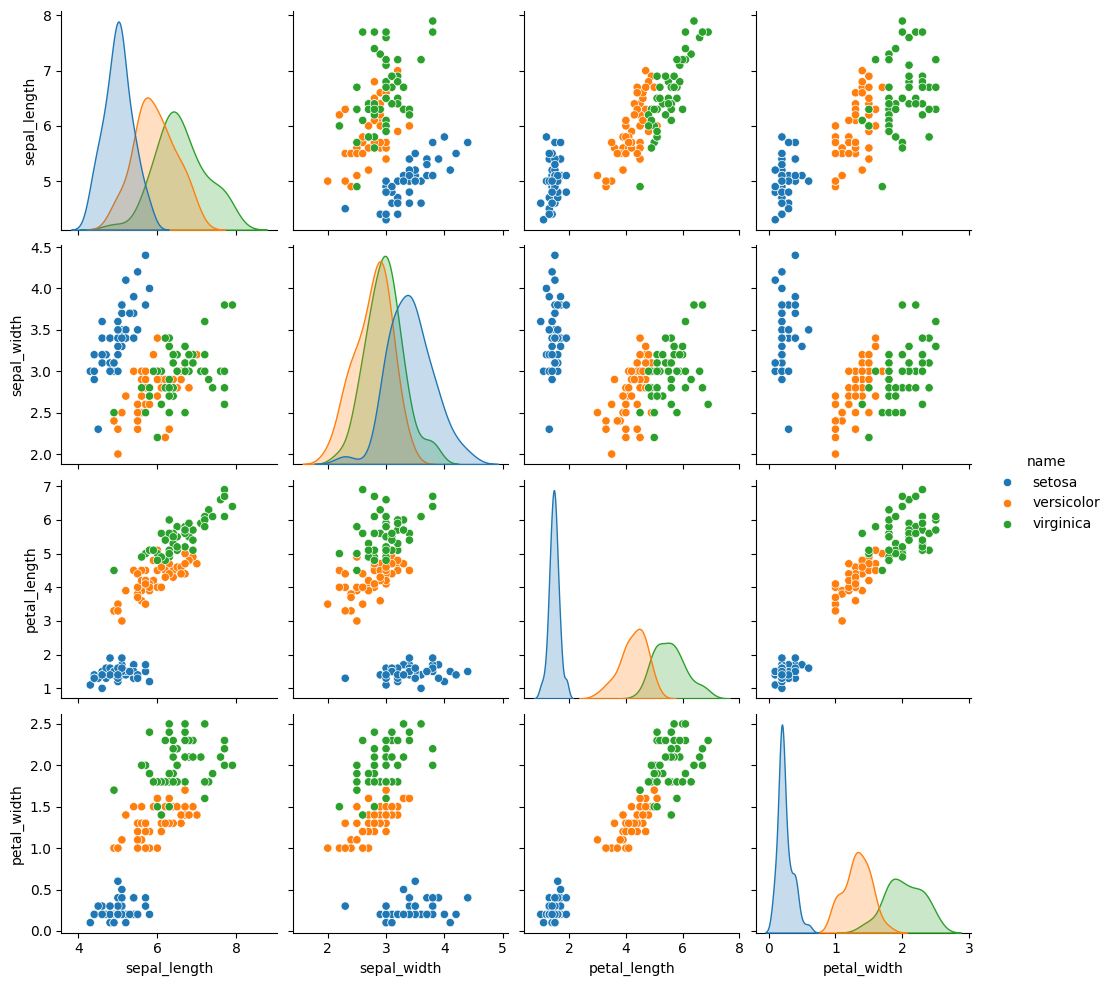

In [38]:
# Create a pairplot grouped by iris species.

sns.pairplot(
    iris,
    vars=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ],
    hue="name"
)

plt.show()

The species are separated most clearly by petal length and petal width. Setosa forms a distinct group, while versicolor and virginica overlap more in some measurements.

### Multiple Regression with Species and Petal Length

This model predicts sepal width using iris species and petal length.

In [39]:
# Fit the multiple regression model.

iris_model = smf.ols(
    formula="sepal_width ~ name + petal_length",
    data=iris
).fit()

iris_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        01:43:05   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0.099     29.989      0.000       2.785       3.178
name[T.versicolor]    -1.4821      0.181     -8.190      0.000      -1.840      -1.124
name[T.virginica]     -1.6635      0.256     -6.502      0.000      -2.169      -1.158
petal_length           0.2983      0.061      4.920      0.000       0.178       0.418
==============================================================================
Omnibus:                        2.868   Durbin-Watson:                   1.753
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                2.885
Skew:                          -0.082   Prob(JB):                        0.236
Kurtosis:                       3.659   Cond. No.                         54.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
# Display coefficient estimates and p-values.

iris_model_results = pd.DataFrame({
    "Coefficient": iris_model.params,
    "P-value": iris_model.pvalues
})

iris_model_results

,Coefficient,P-value
Intercept,2.981274,2.770540e-64
name[T.versicolor],-1.482075,1.199597e-13
name[T.virginica],-1.663492,1.177844e-09
petal_length,0.298310,2.310862e-06


The model explains about 48% of the variation in sepal width. Petal length has a positive and statistically significant coefficient after species is included in the model. The species coefficients are also statistically significant compared with the reference species.

### Comparison of Species Coefficients

The F-test compares the estimated coefficients for versicolor and virginica while controlling for petal length.

In [41]:
# Test whether the versicolor and virginica coefficients are equal.

iris_f_test = iris_model.f_test(
    [0, 1, -1, 0]
)

print(iris_f_test)

<F test: F=3.245335346574177, p=0.0736905878170114, df_denom=146, df_num=1>


The F-test p-value is greater than 0.05. Therefore, the difference between the versicolor and virginica coefficients is not statistically significant after petal length is controlled.

## 5. Wage Dataset

The wage dataset contains information about education, age, work experience, sex, and hourly wage. Wage values are log-transformed before visualization and regression analysis.

In [42]:
# Load the wage dataset.

wages = pd.read_csv(
    "../examples/wages.txt",
    skiprows=27,
    skipfooter=6,
    sep=None,
    header=None,
    engine="python"
)

column_descriptions = [
    "education: Number of years of education",
    "south: 1=person lives in South, 0=person lives elsewhere",
    "sex: 1=female, 0=male",
    "experience: Number of years of work experience",
    "union: 1=union member, 0=not union member",
    "wage: Wage in dollars per hour",
    "age: Age in years",
    "race: Race category",
    "occupation: Occupation category",
    "sector: Employment sector",
    "marr: 0=unmarried, 1=married"
]

wages.columns = [
    description.split(":")[0]
    for description in column_descriptions
]

print("Dataset shape:", wages.shape)

wages.head()

Dataset shape: (534, 11)


,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,1,21,0,5.10,35,2,6,1,1
1,9,0,1,42,0,4.95,57,3,6,1,1
2,12,0,0,1,0,6.67,19,3,6,1,0
3,12,0,0,4,0,4.00,22,3,6,0,0
4,12,0,0,17,0,7.50,35,3,6,0,1


### Wage Data Preparation

The dataset is checked for missing values. Wage is converted to a logarithmic scale, and the numerical sex codes are replaced with category labels.

In [43]:
# Check column types and missing values.

wages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   education   534 non-null    int64  
 1   south       534 non-null    int64  
 2   sex         534 non-null    int64  
 3   experience  534 non-null    int64  
 4   union       534 non-null    int64  
 5   wage        534 non-null    float64
 6   age         534 non-null    int64  
 7   race        534 non-null    int64  
 8   occupation  534 non-null    int64  
 9   sector      534 non-null    int64  
 10  marr        534 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 46.0 KB


In [44]:
# Count missing observations.

wages.isna().sum()

education     0
south         0
sex           0
experience    0
union         0
wage          0
age           0
race          0
occupation    0
sector        0
marr          0
dtype: int64

In [45]:
# Create a copy before transforming variables.

wage_data = wages.copy()

# Log-transform hourly wage.

wage_data["wage"] = np.log10(
    wage_data["wage"]
)

# Convert the numerical sex variable into category labels.

wage_data["sex"] = wage_data["sex"].map({
    0: "male",
    1: "female"
})

wage_data.head()

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,female,21,0,0.707570,35,2,6,1,1
1,9,0,female,42,0,0.694605,57,3,6,1,1
2,12,0,male,1,0,0.824126,19,3,6,1,0
3,12,0,male,4,0,0.602060,22,3,6,0,0
4,12,0,male,17,0,0.875061,35,3,6,0,1


In [46]:
# Confirm that the sex categories were converted correctly.

wage_data["sex"].value_counts()

sex
male      289
female    245
Name: count, dtype: int64

The wage variable was log-transformed because wage values are often right-skewed. The transformation reduces the influence of very high values and makes the variable more suitable for linear regression.

### Wage Summary Statistics

The following tables summarize the continuous variables and compare average values between male and female participants.

In [47]:
# Display descriptive statistics for selected variables.

wage_data[
    ["wage", "age", "education", "experience"]
].describe()

,wage,age,education,experience
count,534.000000,534.000000,534.000000,534.000000
mean,0.894294,36.833333,13.018727,17.822097
std,0.229196,11.726573,2.615373,12.379710
min,0.000000,18.000000,2.000000,0.000000
25%,0.720159,28.000000,12.000000,8.000000
50%,0.890980,35.000000,12.000000,15.000000
75%,1.051153,44.000000,15.000000,26.000000
max,1.648360,64.000000,18.000000,55.000000


In [48]:
# Calculate group summaries by sex.

wage_summary = wage_data.groupby("sex").agg(
    sample_size=("wage", "size"),
    mean_log_wage=("wage", "mean"),
    mean_education=("education", "mean"),
    mean_age=("age", "mean"),
    mean_experience=("experience", "mean")
)

wage_summary

,sample_size,mean_log_wage,mean_education,mean_age,mean_experience
sex,,,,,
female,245,0.839942,13.024490,37.840816,18.832653
male,289,0.940372,13.013841,35.979239,16.965398


The group summaries show differences in average log wage and other characteristics. Regression analysis is needed to examine whether wage differences remain after education is included in the model.

### Relationships Among Wage, Age, and Education

The pairplot displays distributions and fitted regression lines for the three continuous variables.

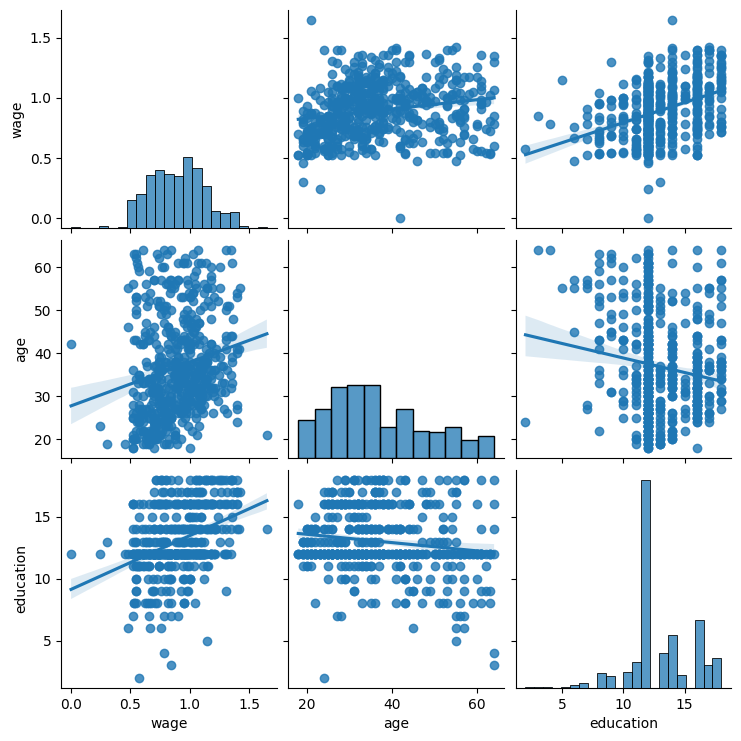

In [49]:
# Create a pairplot for wage, age, and education.

sns.pairplot(
    wage_data,
    vars=["wage", "age", "education"],
    kind="reg"
)

plt.show()

The plots suggest a positive relationship between education and log-transformed wage. The relationship between age and wage appears weaker and may not be completely linear.

### Relationships Grouped by Sex

The same variables are plotted separately for male and female participants.

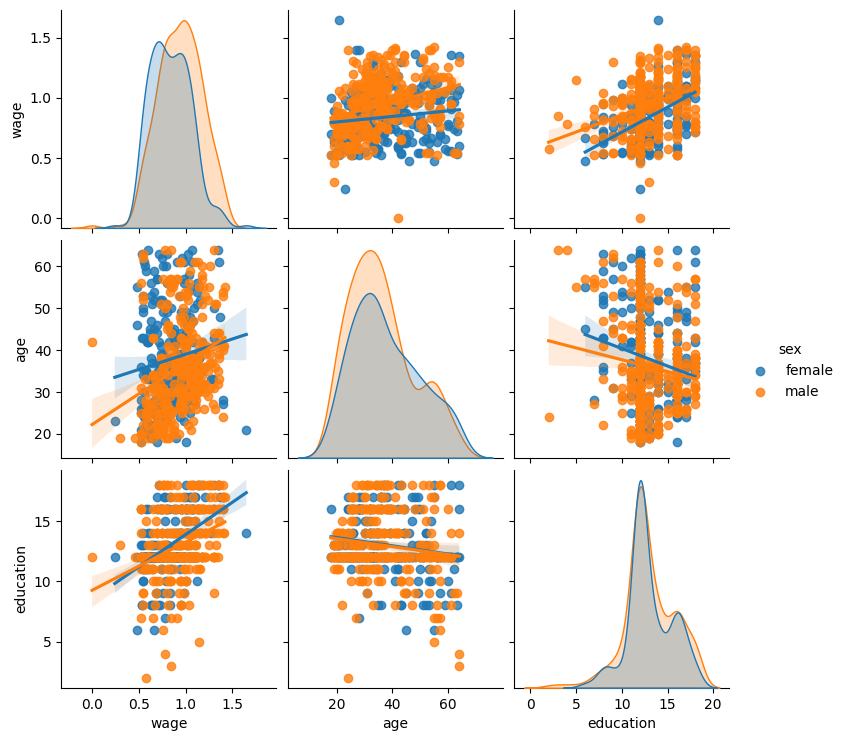

In [50]:
# Compare the variable relationships by sex.

sns.pairplot(
    wage_data,
    vars=["wage", "age", "education"],
    kind="reg",
    hue="sex"
)

plt.show()

The two groups overlap, but their fitted regression lines are not identical. This suggests that sex may be related to wage and may also influence the relationship between education and wage.

### Education and Wage

This plot focuses on the relationship between education and log-transformed wage.

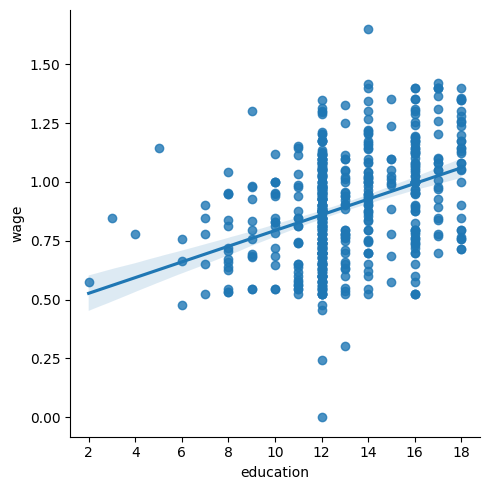

In [51]:
# Plot education against log-transformed wage.

sns.lmplot(
    data=wage_data,
    x="education",
    y="wage"
)

plt.show()

The fitted regression line shows that participants with more years of education generally have higher log-transformed wages.

### Additive Regression Model

The first model includes education and sex as separate predictors. It assumes that the effect of education is the same for male and female participants.

In [52]:
# Fit a model without an interaction.

wage_additive_model = smf.ols(
    formula="wage ~ education + sex",
    data=wage_data
).fit()

wage_additive_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        01:43:09   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4053      0.046      8.732      0.000       0.314       0.496
sex[T.male]     0.1008      0.018      5.625      0.000       0.066       0.136
education       0.0334      0.003      9.768      0.000       0.027       0.040
==============================================================================
Omnibus:                        4.675   Durbin-Watson:                   1.792
Prob(Omnibus):                  0.097   Jarque-Bera (JB):                4.876
Skew:                          -0.147   Prob(JB):                       0.0873
Kurtosis:                       3.365   Cond. No.                         69.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
# Display the main estimates from the additive model.

wage_additive_results = pd.DataFrame({
    "Coefficient": wage_additive_model.params,
    "Standard Error": wage_additive_model.bse,
    "P-value": wage_additive_model.pvalues
})

wage_additive_results

,Coefficient,Standard Error,P-value
Intercept,0.405251,0.046412,3.271932e-17
sex[T.male],0.100785,0.017916,2.998884e-08
education,0.033375,0.003417,7.752056e-21


Education and sex both have p-values below 0.05, so they are statistically significant predictors of log-transformed wage. The positive education coefficient indicates that predicted wage increases as years of education increase. The coefficient for `sex[T.male]` indicates that male participants have a higher predicted wage than female participants when education is held constant.

### Education and Wage by Sex

Separate regression lines are used to examine whether the education-wage relationship appears different between the two groups.

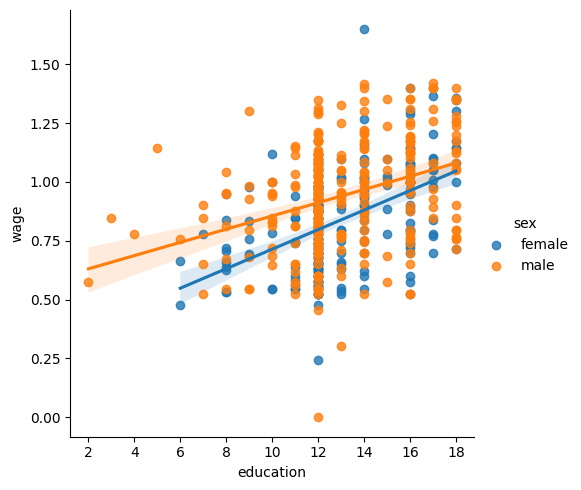

In [54]:
# Plot separate education-wage regression lines by sex.

sns.lmplot(
    data=wage_data,
    x="education",
    y="wage",
    hue="sex"
)

plt.show()

The regression lines have different intercepts and slightly different slopes. An interaction model is needed to test whether the slope difference is statistically significant.

### Regression Model with an Interaction

The interaction term tests whether the effect of education on wage differs between male and female participants.

In [55]:
# Fit a model containing an interaction between education and sex.

wage_interaction_model = smf.ols(
    formula="wage ~ education * sex",
    data=wage_data
).fit()

wage_interaction_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        01:43:10   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.2998      0.072      4.173      0.000       0.159       0.441
sex[T.male]               0.2750      0.093      2.972      0.003       0.093       0.457
education                 0.0415      0.005      7.647      0.000       0.031       0.052
education:sex[T.male]    -0.0134      0.007     -1.919      0.056      -0.027       0.000
==============================================================================
Omnibus:                        4.838   Durbin-Watson:                   1.825
Prob(Omnibus):                  0.089   Jarque-Bera (JB):                5.000
Skew:                          -0.156   Prob(JB):                       0.0821
Kurtosis:                       3.356   Cond. No.                         194.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [56]:
# Display the coefficients and p-values.

wage_interaction_results = pd.DataFrame({
    "Coefficient": wage_interaction_model.params,
    "Standard Error": wage_interaction_model.bse,
    "P-value": wage_interaction_model.pvalues
})

wage_interaction_results

,Coefficient,Standard Error,P-value
Intercept,0.299822,0.071848,3.512968e-05
sex[T.male],0.274974,0.092520,3.092571e-03
education,0.041470,0.005423,9.767921e-14
education:sex[T.male],-0.013378,0.006972,5.553993e-02


The interaction coefficient for `education:sex[T.male]` is negative, which suggests that the education slope is slightly smaller for male participants than for female participants. However, the p-value is slightly greater than 0.05, so the interaction is not statistically significant at the conventional 0.05 level. The data therefore do not provide enough evidence that the effect of education on wage differs between the two groups.

### Comparison of the Two Wage Models

The additive model and interaction model are compared using R-squared, adjusted R-squared, and AIC.

In [57]:
# Compare the fit statistics of the two models.

wage_model_comparison = pd.DataFrame({
    "Model": [
        "Additive model",
        "Interaction model"
    ],
    "R-squared": [
        wage_additive_model.rsquared,
        wage_interaction_model.rsquared
    ],
    "Adjusted R-squared": [
        wage_additive_model.rsquared_adj,
        wage_interaction_model.rsquared_adj
    ],
    "AIC": [
        wage_additive_model.aic,
        wage_interaction_model.aic
    ]
})

wage_model_comparison

,Model,R-squared,Adjusted R-squared,AIC
0,Additive model,0.192806,0.189766,-167.308847
1,Interaction model,0.198375,0.193838,-169.005799


The interaction model has a slightly higher R-squared value, but the improvement is small. Because the interaction term is not statistically significant, the simpler additive model may be easier to interpret without losing much explanatory value.

## 6. Conclusion

This AI-assisted analysis used data inspection, descriptive statistics, hypothesis tests, regression models, and visualizations to examine several datasets. The brain-size analysis did not find a significant difference in VIQ between female and male participants, but it did find a significant difference in mean weight. The paired IQ tests did not show a significant difference between FSIQ and PIQ.

The multiple regression analysis showed that gender was not a significant predictor of VIQ after MRI count, height, and weight were controlled. In the iris dataset, species and petal length were useful predictors of sepal width. In the wage dataset, education and sex were significant predictors of log-transformed wage, but the education-by-sex interaction was not statistically significant.

Overall, the results show why effect estimates, p-values, model assumptions, and model fit should all be considered when interpreting statistical analyses.

## Sources

The analysis was supported by the SciPy Lecture Notes and the official documentation for SciPy, pandas, Statsmodels, Matplotlib, and Seaborn.